In [ ]:
!pip install venn

from google.colab import drive
drive.mount('/content/drive')

  Preparing metadata (setup.py) ... done
  Created wheel for venn: filename=venn-0.1.3-py3-none-any.whl size=19701 sha256=7800e493904a5211e85726080e24682d3dd87405a8b56ecf3c5b612474da2883
  Stored in directory: /root/.cache/pip/wheels/a9/66/8d/f184df1b62184b9367463edd23ac584f3ed5c7e695a6a5f222
Successfully built venn
Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif , mutual_info_classif
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, roc_auc_score, matthews_corrcoef, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, classification_report
from  lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
from joblib import parallel_backend
import os
import ipaddress
import shap
from sklearn.metrics import matthews_corrcoef
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, matthews_corrcoef
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.features import FeatureImportances
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from matplotlib_venn import venn2
from sklearn.inspection import permutation_importance
from matplotlib_venn import venn3
from venn import venn

In [ ]:


#!ls "/content/drive/My Drive/Colab Notebooks"

Mounted at /content/drive


In [ ]:
file_path_train = "/content/drive/My Drive/Colab Notebooks/kdd/KDDTrain+.txt"
file_path_test = "/content/drive/My Drive/Colab Notebooks/kdd/KDDTest+.txt"

data = pd.read_csv(file_path_train)
train_df = data.copy()


datatest = pd.read_csv(file_path_test)

test_df = datatest.copy()
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level'])

train_df.columns = columns
test_df.columns = columns


attack_mapping = {
    # DoS
    'back': 'DoS',
    'land': 'DoS',
    'neptune': 'DoS',
    'pod': 'DoS',
    'smurf': 'DoS',
    'teardrop': 'DoS',
    'apache2': 'DoS',
    'udpstorm': 'DoS',
    'processtable': 'DoS',
    'mailbomb': 'DoS',

    # Probe
    'satan': 'Probe',
    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',
    'mscan': 'Probe',
    'saint': 'Probe',

    # R2L
    'ftp_write': 'R2L',
    'guess_passwd': 'R2L',
    'imap': 'R2L',
    'multihop': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'warezclient': 'R2L',
    'warezmaster': 'R2L',
    'snmpgetattack': 'R2L',
    'snmpguess': 'R2L',
    'httptunnel': 'R2L',
    'sendmail': 'R2L',
    'named': 'R2L',
    'xlock': 'R2L',
    'xsnoop': 'R2L',
    'worm': 'R2L',

    # U2R
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R',
    'ps': 'U2R',
    'sqlattack': 'U2R',
    'xterm': 'U2R',

    # Normal
    'normal': 'Normal'
}


train_df['attack_category'] = train_df['attack'].map(attack_mapping)
test_df['attack_category'] = test_df['attack'].map(attack_mapping)

full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)


print(f"Shape before behavioral deduplication: {full_df.shape}")
full_df = full_df.drop_duplicates()
print(f"Shape after behavioral deduplication: {full_df.shape}")


X_global = full_df.drop(columns=['attack_category','level','attack'])
y_global = full_df['attack_category']

X_train_global, X_temp, y_train_global, y_temp = train_test_split(
    X_global,
    y_global,
    test_size=0.30,           # 30% goes to temp
    random_state=42,
    stratify=y_global
)

X_val_global, X_test_global, y_val_global, y_test_global = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,           # half of temp → 15% of total
    random_state=42,
    stratify=y_temp
)

train_df = X_train_global.copy()
train_df['attack_category'] = y_train_global.values

val_df = X_val_global.copy()
val_df['attack_category'] = y_val_global.values

test_df = X_test_global.copy()
test_df['attack_category'] = y_test_global.values


print(train_df['attack_category'].value_counts())
print(val_df['attack_category'].value_counts())
print(test_df['attack_category'].value_counts())


attack_category
Normal    53937
DoS       37369
Probe      9854
R2L        2717
U2R          83
Name: count, dtype: int64
attack_category
Normal    11558
DoS        8007
Probe      2111
R2L         583
U2R          18
Name: count, dtype: int64
attack_category
Normal    11558
DoS        8008
Probe      2112
R2L         582
U2R          18
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import OneHotEncoder

def fit_ohe(df, categorical_cols):
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe.fit(df[categorical_cols])
    return ohe

def transform_ohe(df, categorical_cols, ohe):
    ohe_cols = ohe.get_feature_names_out(categorical_cols)
    ohe_vals = ohe.transform(df[categorical_cols])
    df = df.drop(columns=categorical_cols)
    df[ohe_cols] = ohe_vals
    return df

categorical_cols = ['protocol_type', 'service', 'flag'] # Fit only on train
ohe = fit_ohe(train_df, categorical_cols)


ohe = fit_ohe(train_df, categorical_cols) # Transform both using the SAME encoder
train_df = transform_ohe(train_df, categorical_cols, ohe)
val_df = transform_ohe(val_df,categorical_cols, ohe)
test_df = transform_ohe(test_df, categorical_cols, ohe)



In [ ]:
print(train_df.dtypes)


duration            int64
src_bytes           int64
dst_bytes           int64
land                int64
wrong_fragment      int64
                   ...   
flag_S1           float64
flag_S2           float64
flag_S3           float64
flag_SF           float64
flag_SH           float64
Length: 122, dtype: object


# Feature selection for inbalanced

In [ ]:
def plot_feature_importance(
    data, x_col, y_col, title, xlabel, ylabel,
    save_path=None, label=None, color="#ADD8E6",
    figsize=(7, 5), dpi=300,
    axis_label_size=12, tick_label_size=10, annot_size=12
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.0)

    # Adjust height automatically for many features
    n = len(data)
    if figsize is None:
        height = max(4, 0.25 * n)   # 0.25 inch per feature as a rule of thumb
        figsize = (7, height)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    ax = sns.barplot(data=data, x=x_col, y=y_col, palette=[color] * n, ax=ax)

    # Axis labels and ticks
    ax.set_title(title, fontsize=axis_label_size)
    ax.set_xlabel(xlabel, fontsize=axis_label_size)
    ax.set_ylabel(ylabel, fontsize=axis_label_size)
    ax.tick_params(axis='x', labelsize=tick_label_size)
    ax.tick_params(axis='y', labelsize=tick_label_size)

    # Add bar labels (works for horizontal bars)
    try:
        # Matplotlib 3.4+: bar_label places labels nicely
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f',label_type='center', padding=0, fontsize=annot_size)
    except Exception:
        # Fallback: manual text placement
        for i, v in enumerate(data[x_col]):
            ax.text(v + 0.01 * data[x_col].max(), i, f"{v:.2f}",
                    va='center', fontsize=annot_size)

    plt.tight_layout()
    if save_path:
        # Prefer vector format for journals: .pdf or .svg
        fig.savefig(save_path, bbox_inches='tight')
    plt.show()


In [ ]:
train_df['attack_category'] = train_df['attack_category'].apply(lambda x: 'normal' if x.lower() == 'normal' else 'Malicious')
print(train_df['attack_category'].value_counts())


attack_category
normal       53937
Malicious    50023
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [16] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/tmp/ipykernel_9872/2715321623.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=data, x=x_col, y=y_col, palette=[color] * n, ax=ax)


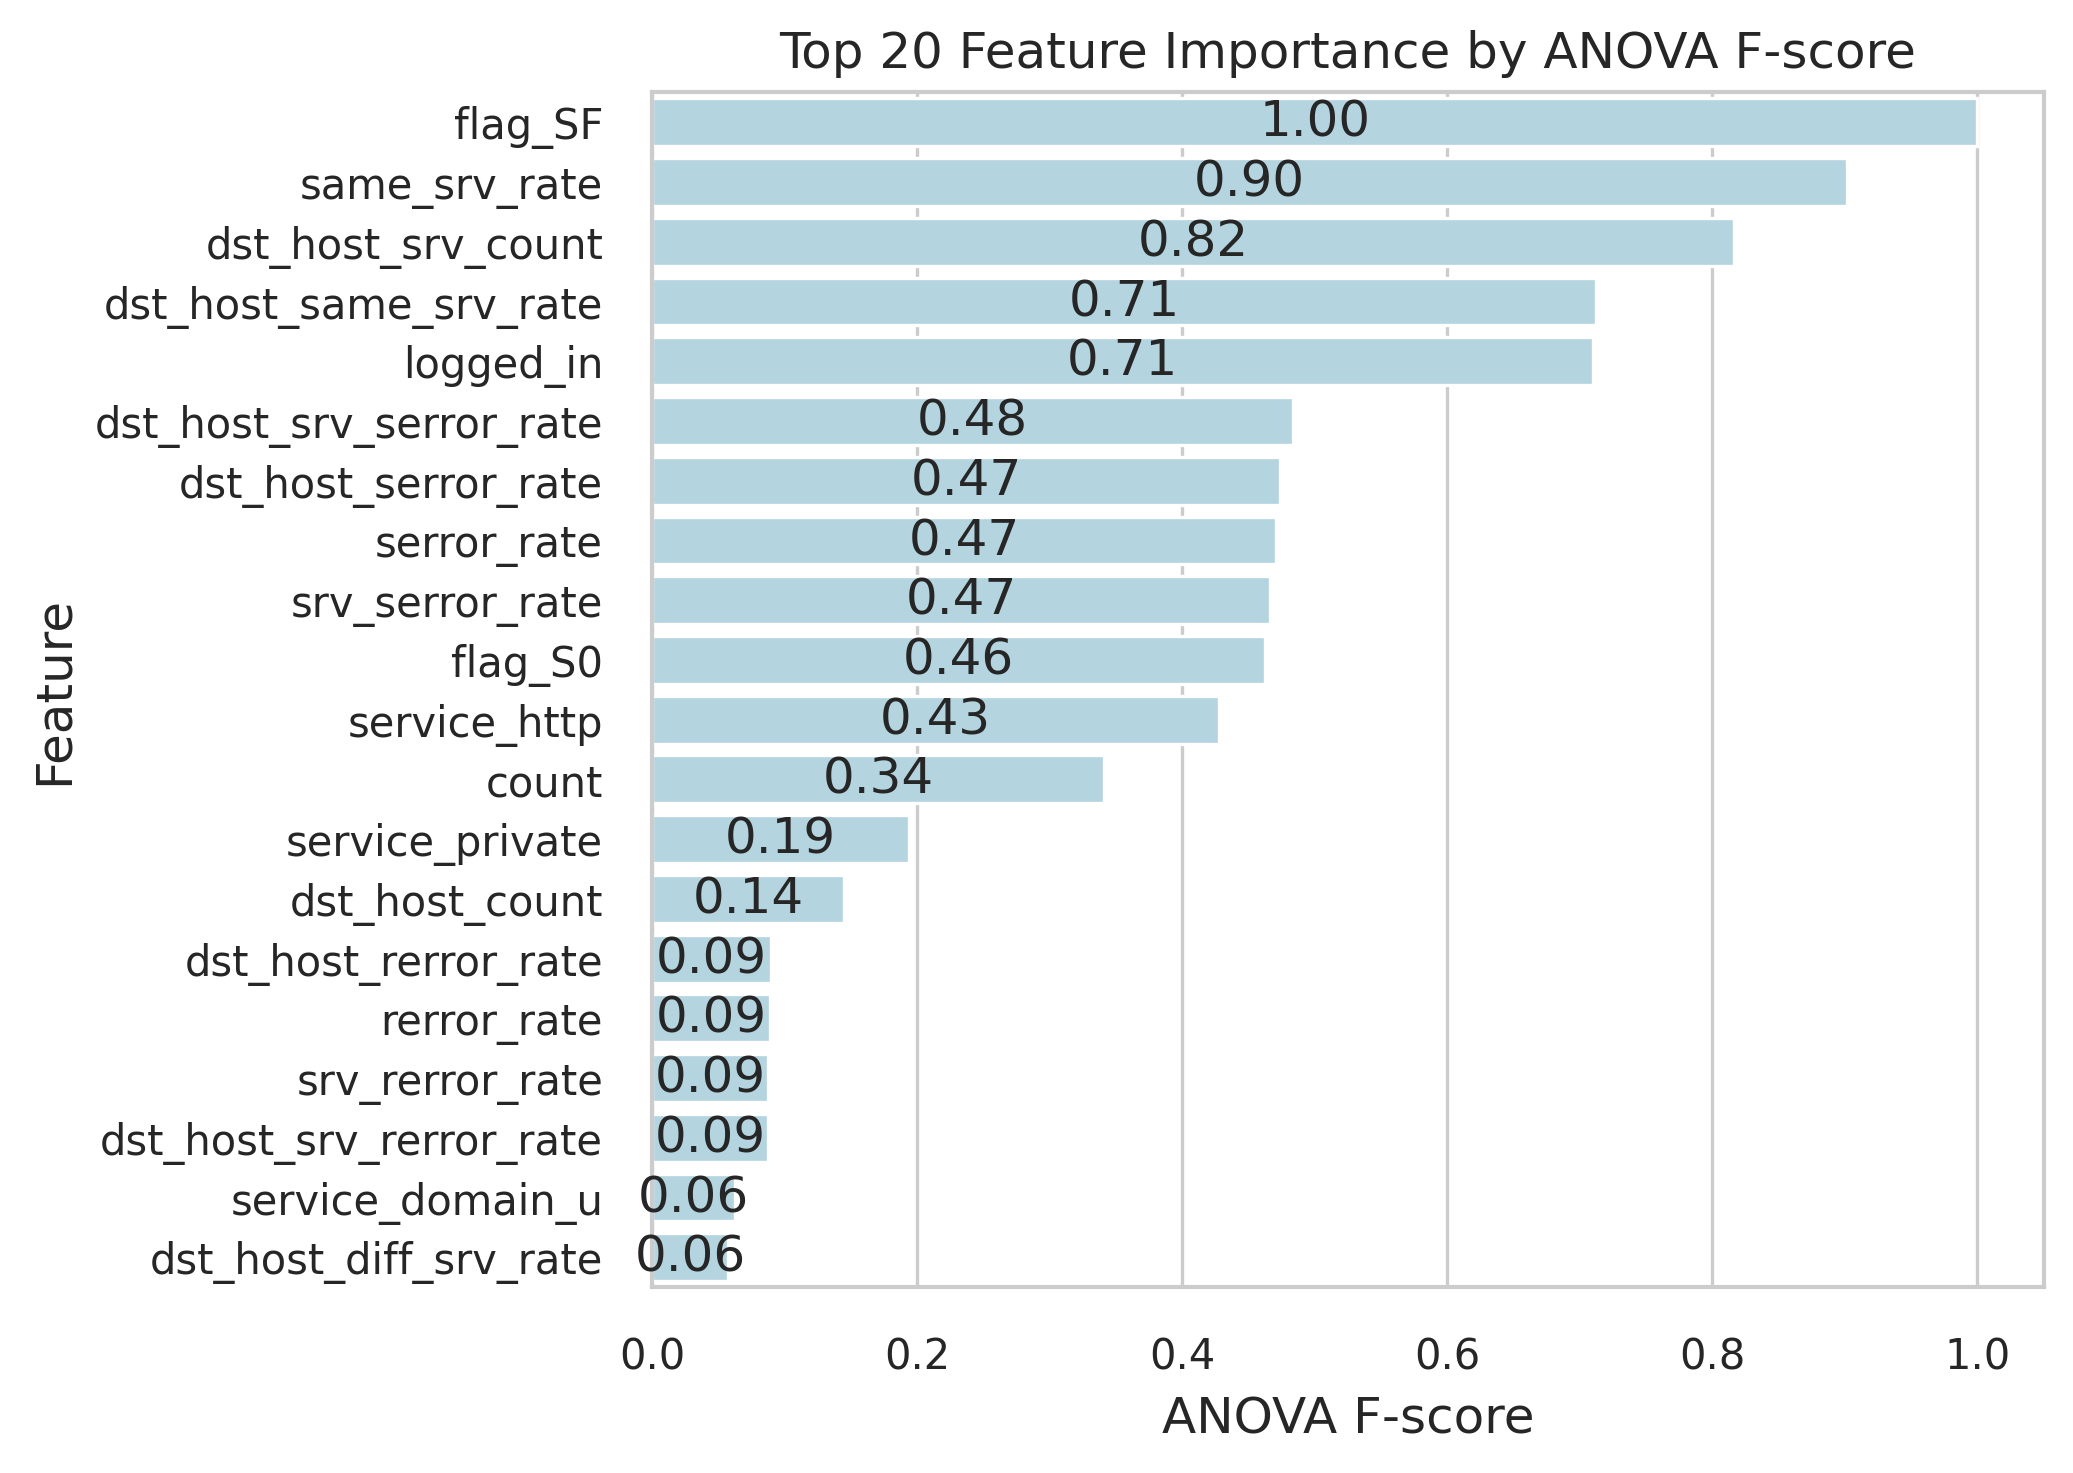

[LightGBM] [Info] Number of positive: 53937, number of negative: 50023
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012707 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3348
[LightGBM] [Info] Number of data points in the train set: 103960, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.518825 -> initscore=0.075334
[LightGBM] [Info] Start training from score 0.075334


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_9872/2715321623.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=data, x=x_col, y=y_col, palette=[color] * n, ax=ax)


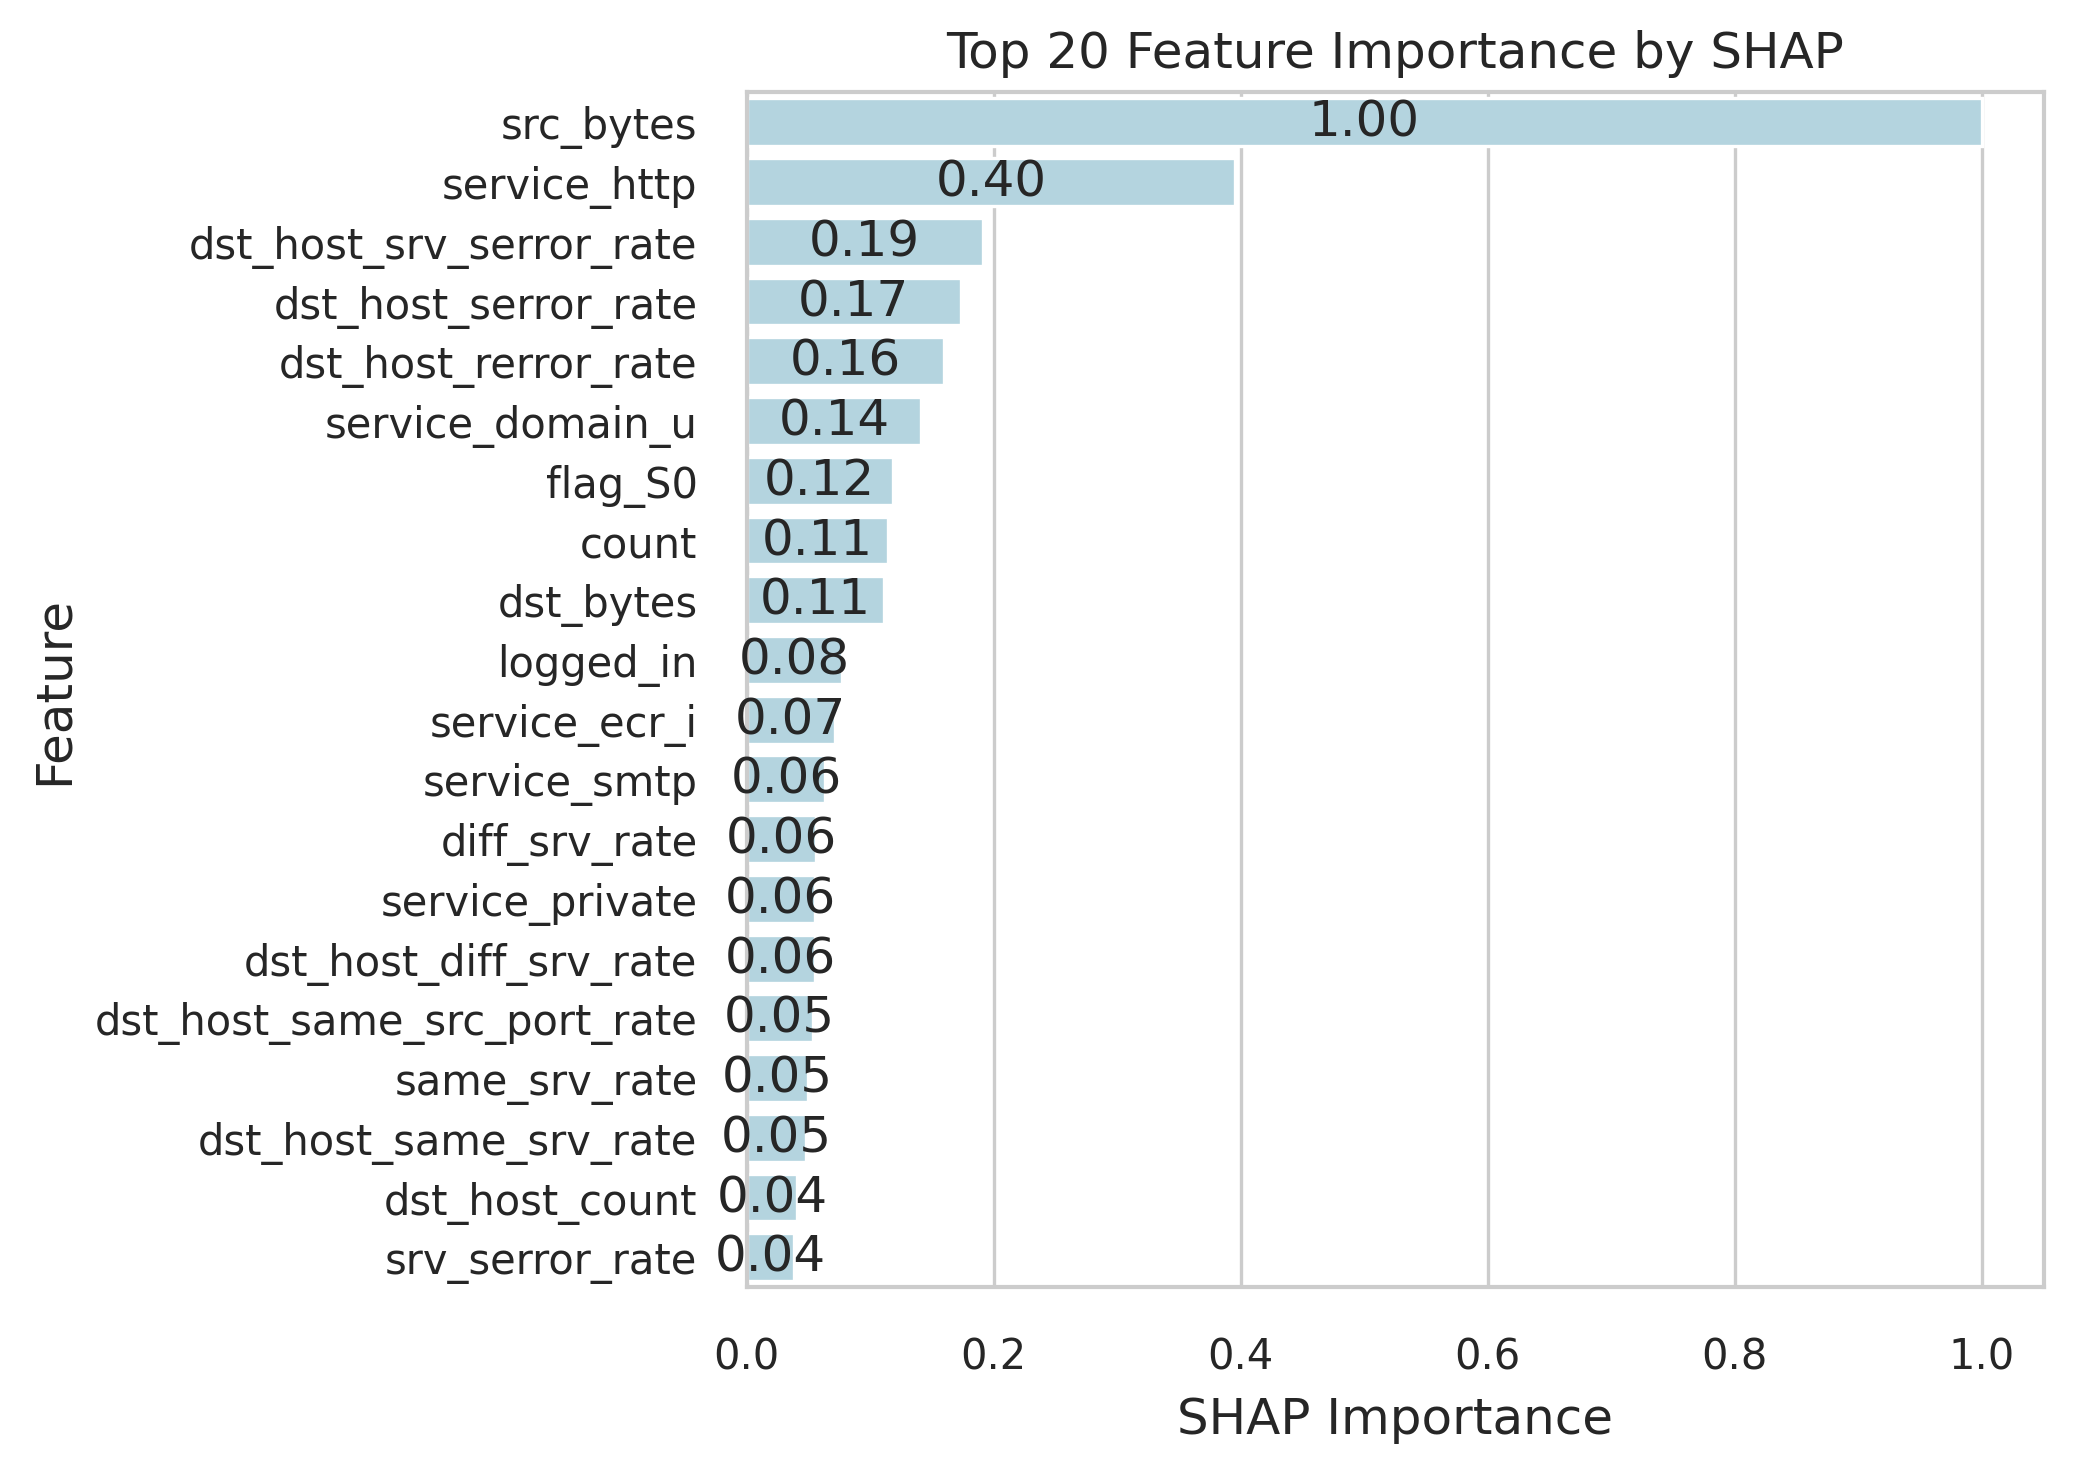

/tmp/ipykernel_9872/2715321623.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=data, x=x_col, y=y_col, palette=[color] * n, ax=ax)


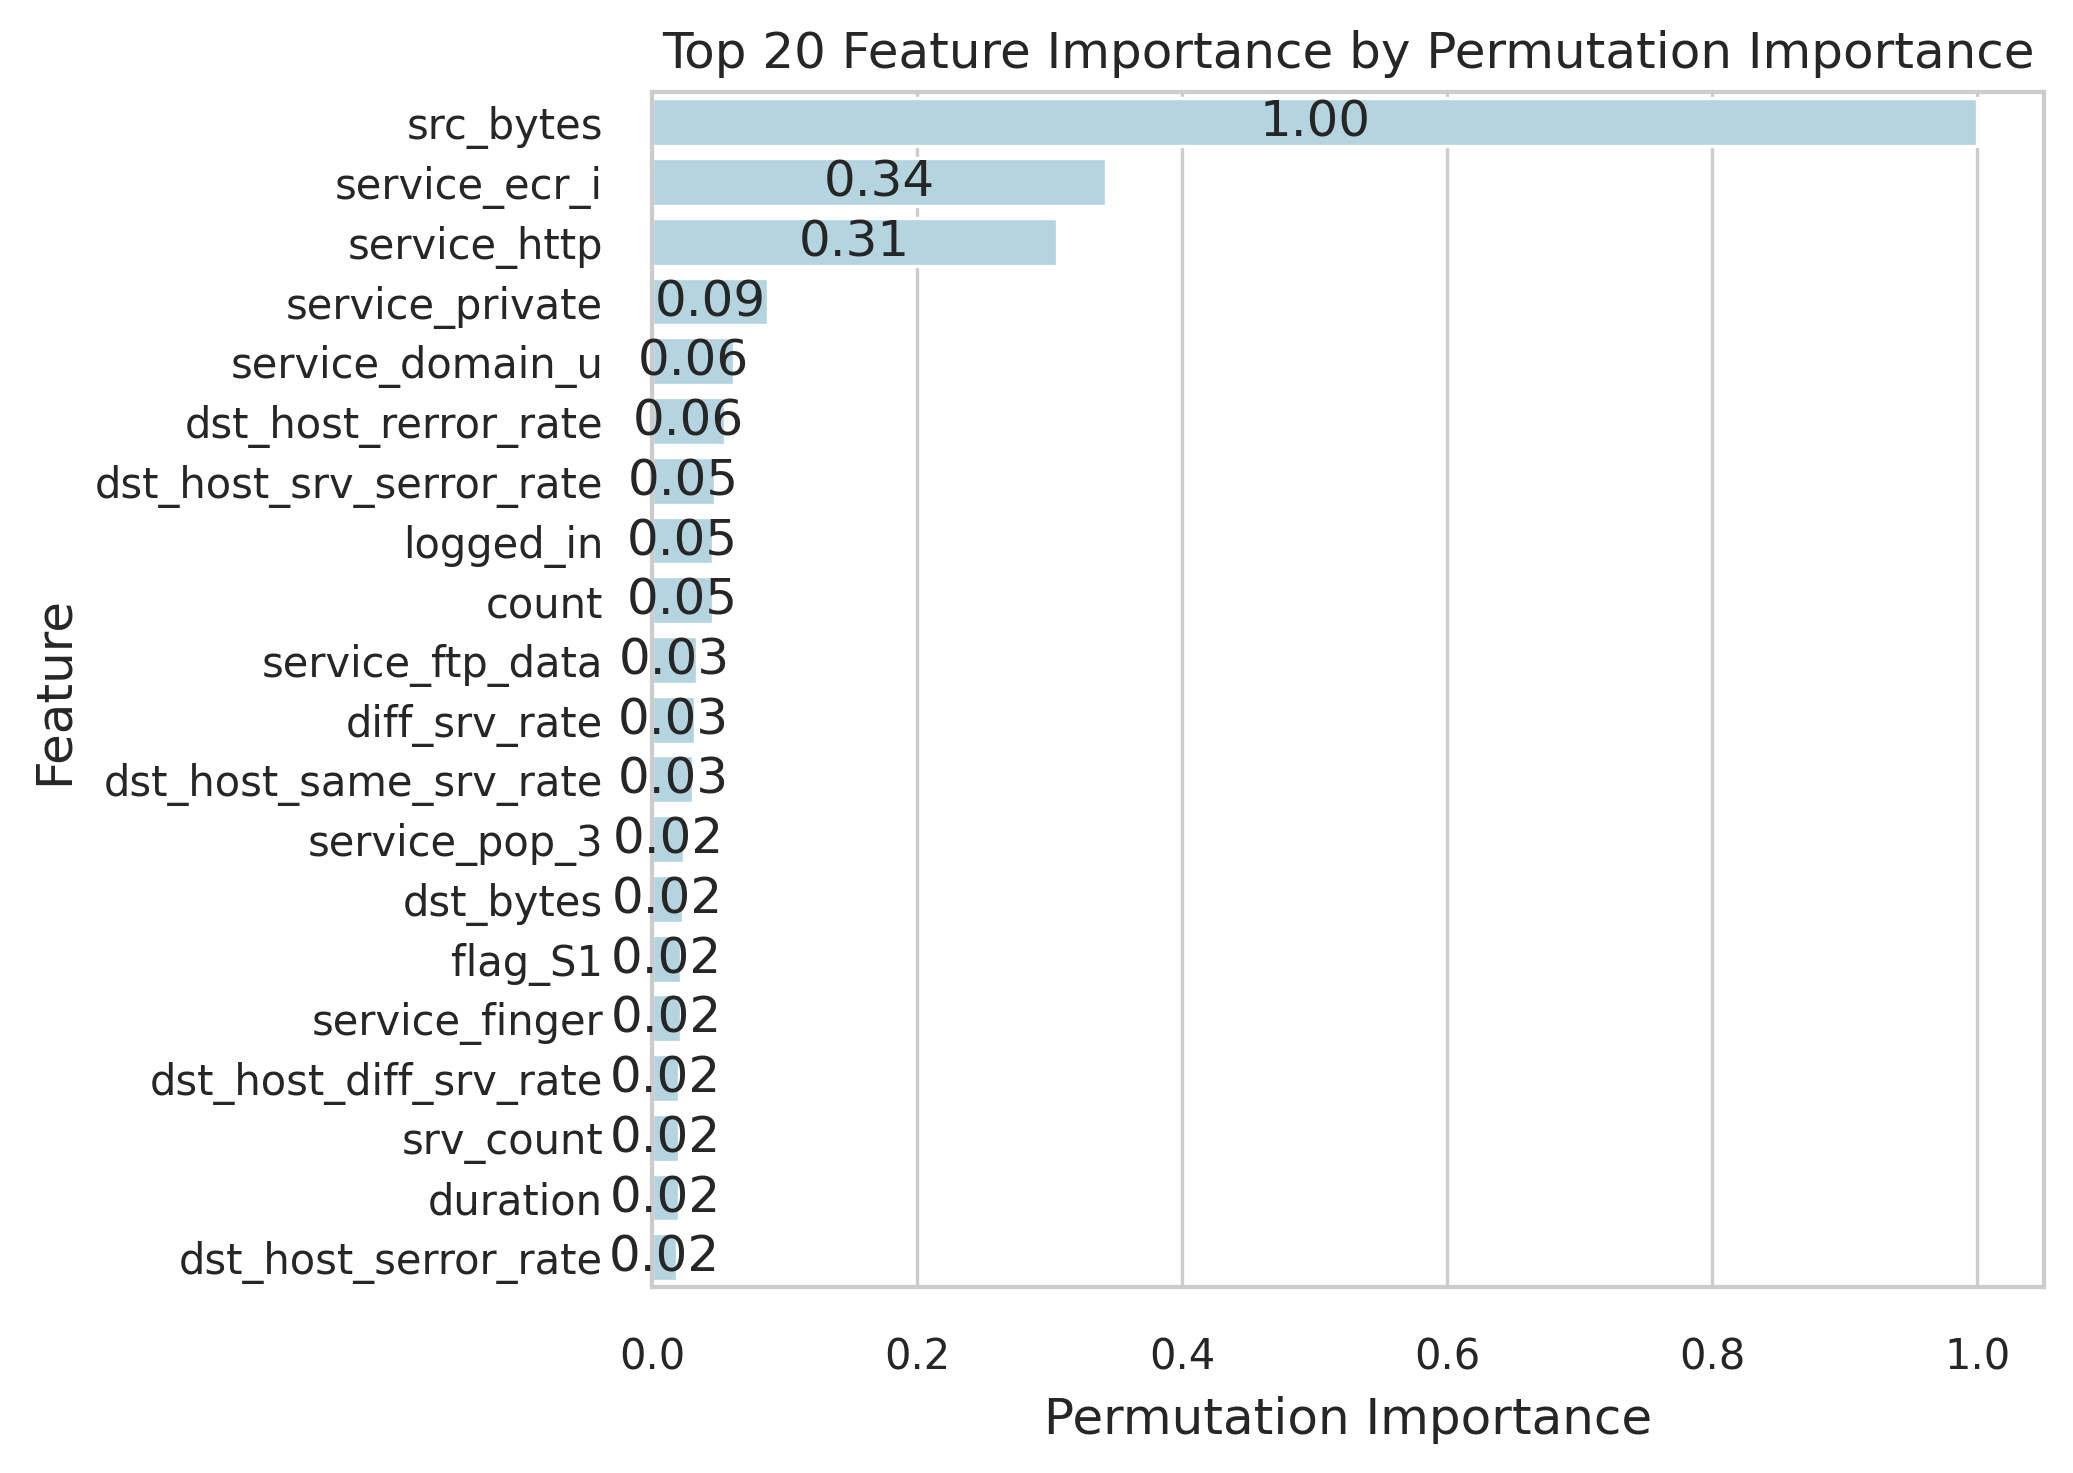

/tmp/ipykernel_9872/2715321623.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=data, x=x_col, y=y_col, palette=[color] * n, ax=ax)


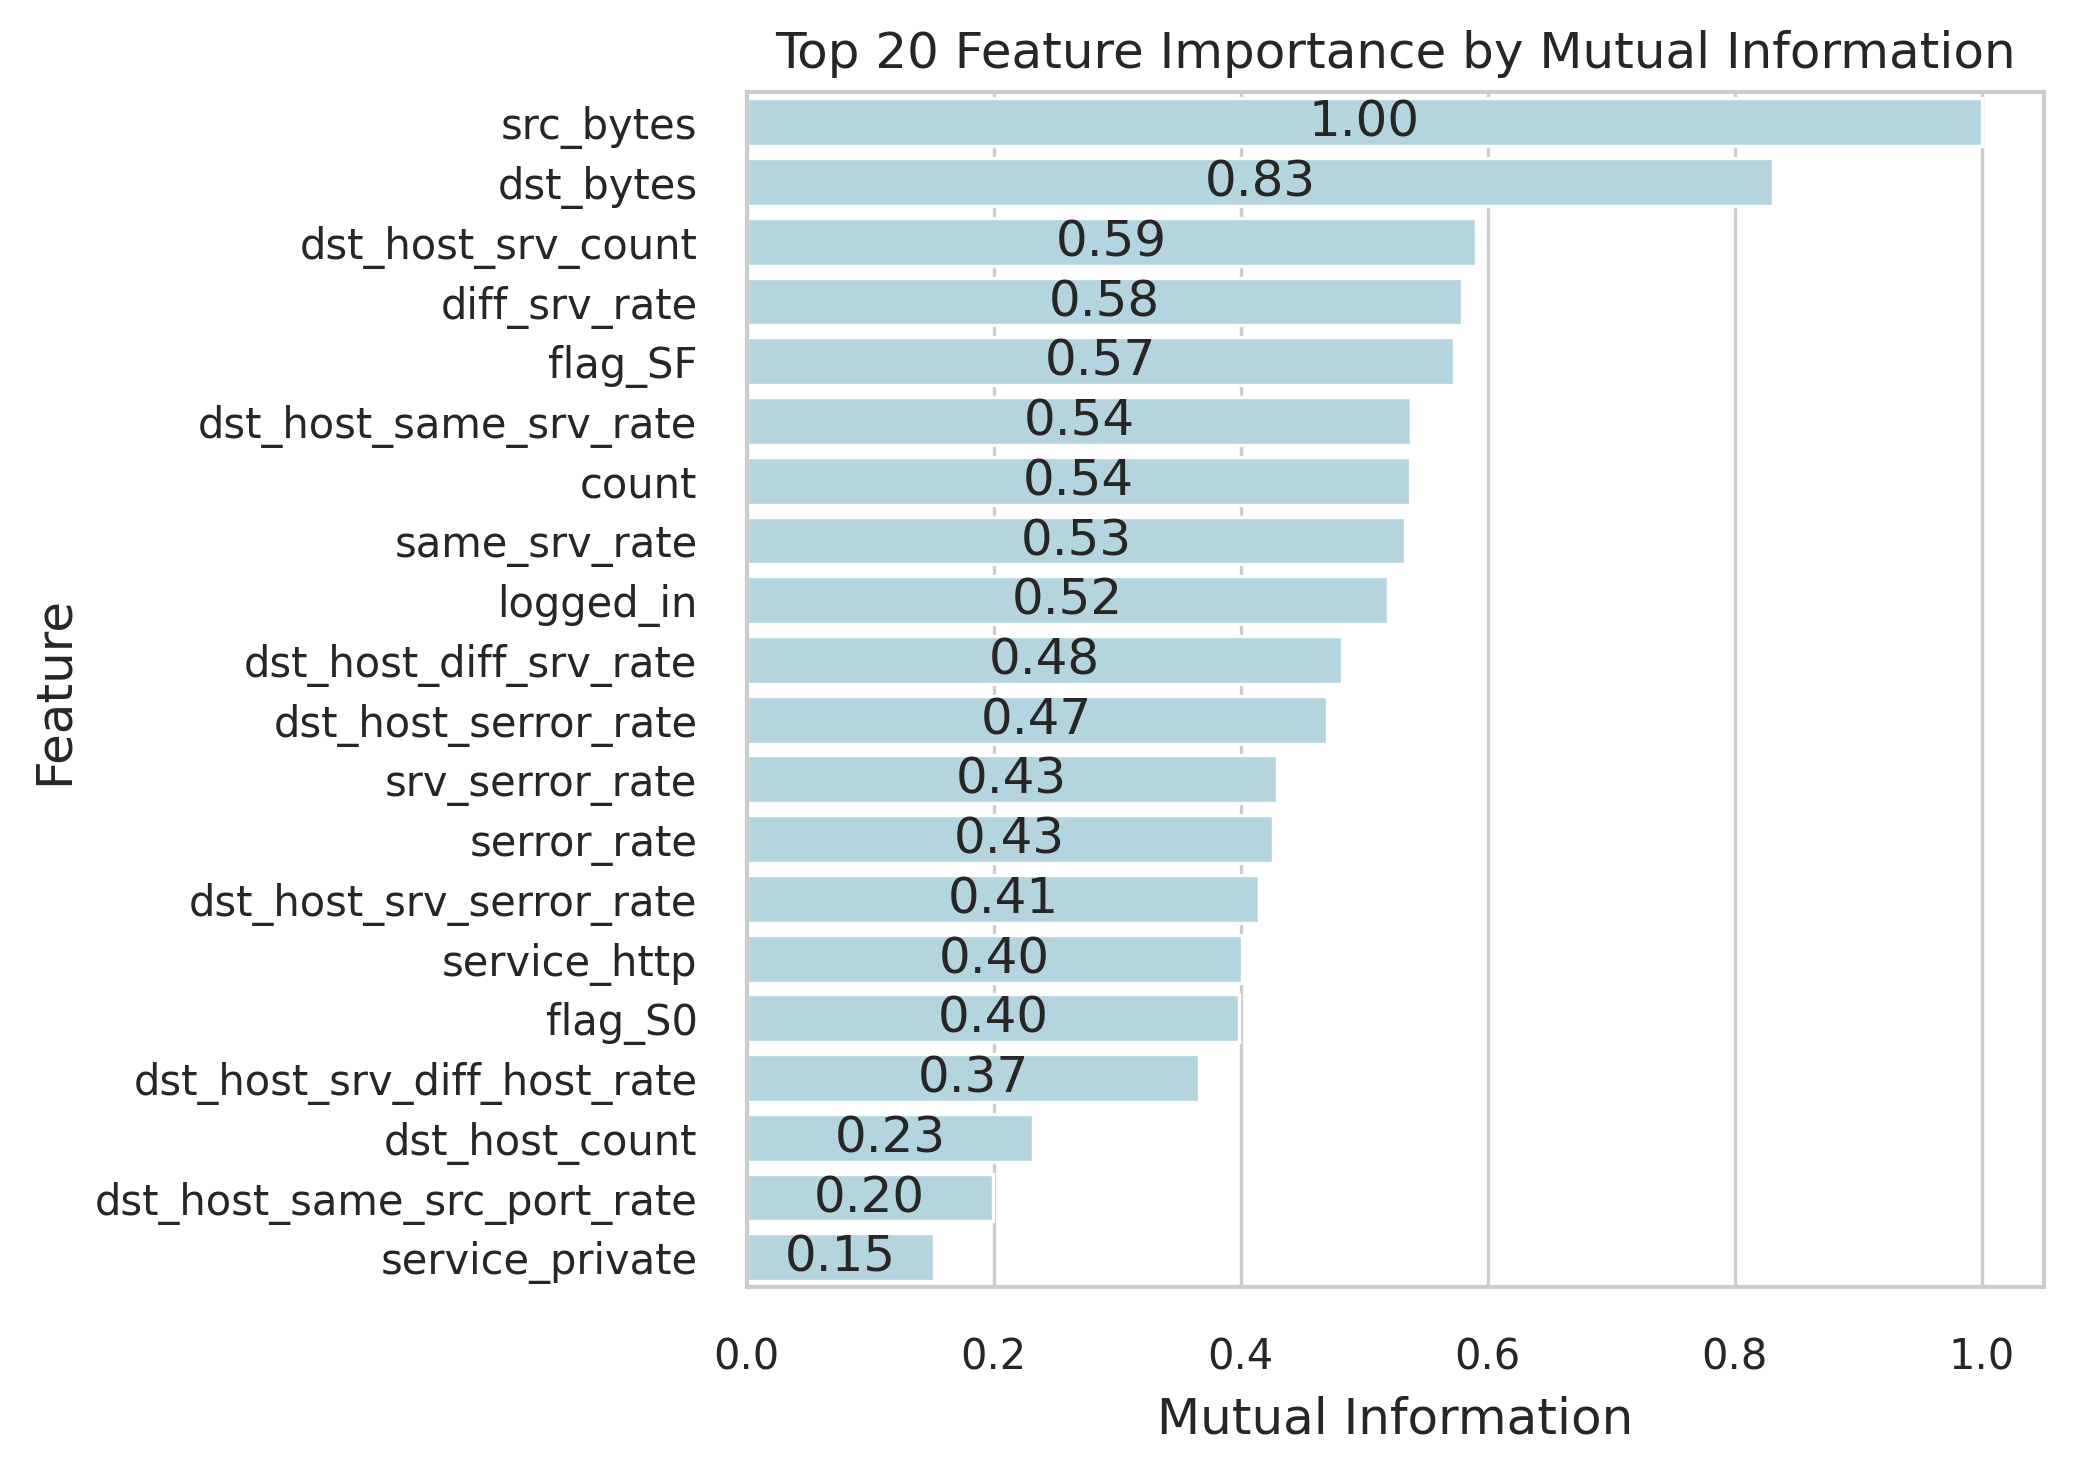

{'same_srv_rate', 'diff_srv_rate', 'dst_host_srv_serror_rate', 'dst_host_same_srv_rate', 'serror_rate', 'logged_in', 'src_bytes', 'dst_host_count', 'count', 'dst_host_diff_srv_rate', 'flag_SF', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_bytes', 'dst_host_serror_rate', 'dst_host_srv_count', 'srv_serror_rate', 'service_private', 'service_http', 'flag_S0'}


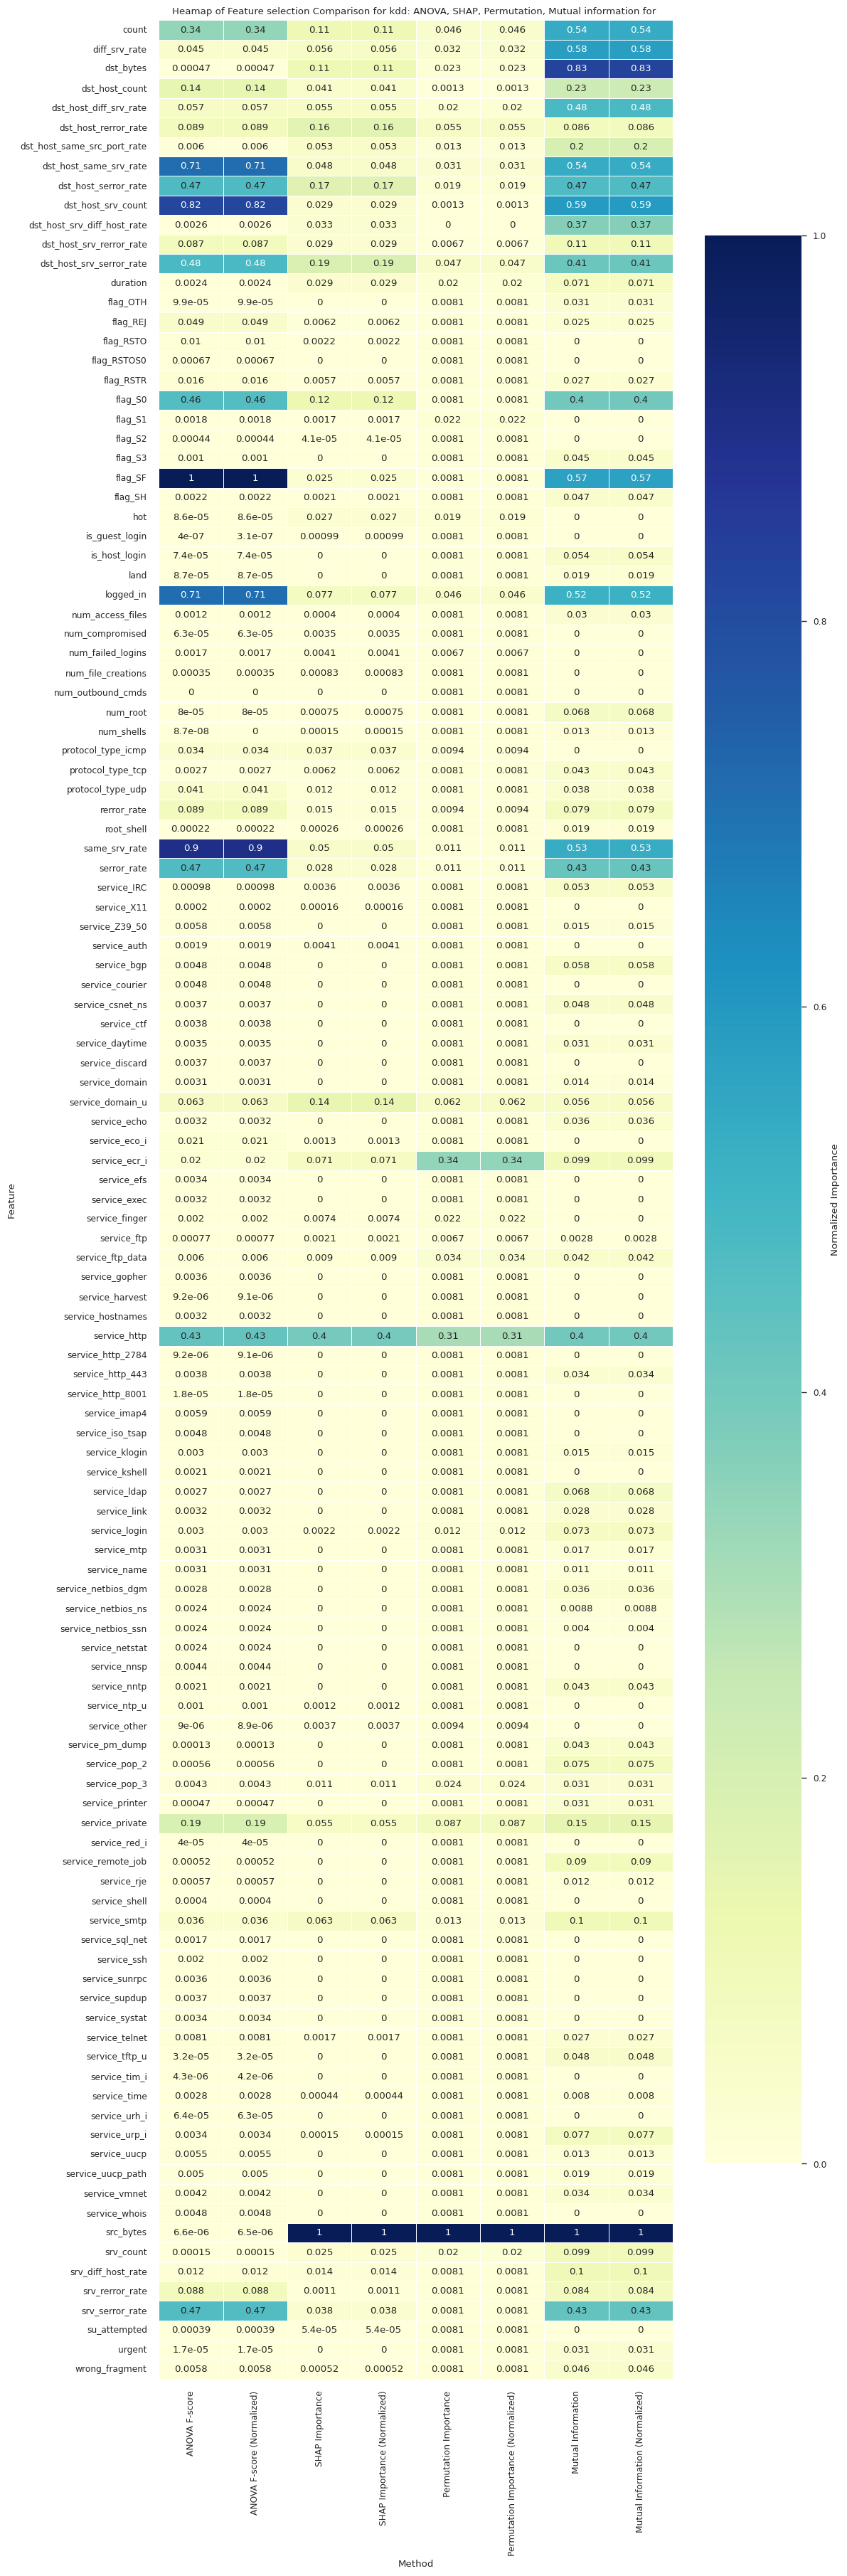

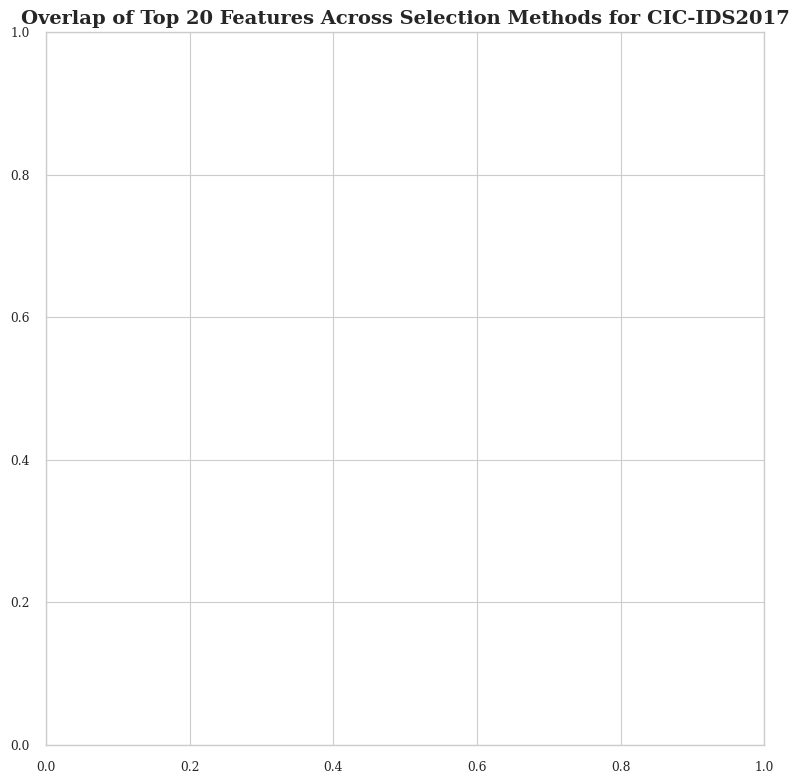

Features in all four sets (8):
count, dst_host_diff_srv_rate, dst_host_same_srv_rate, dst_host_serror_rate, dst_host_srv_serror_rate, logged_in, service_http, service_private


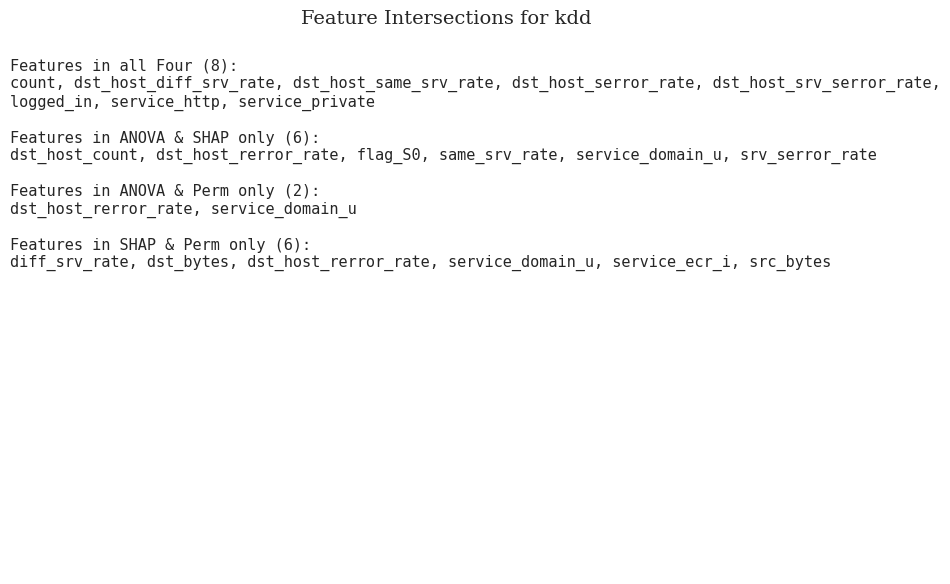

<Figure size 1000x1000 with 0 Axes>

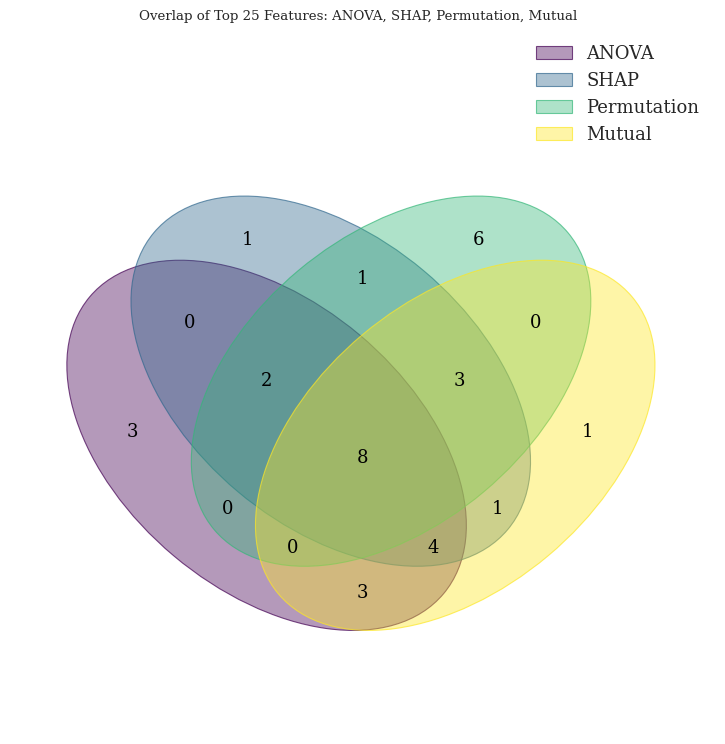

Features in all four sets (8):
count, dst_host_diff_srv_rate, dst_host_same_srv_rate, dst_host_serror_rate, dst_host_srv_serror_rate, logged_in, service_http, service_private
Distinct feature  {'same_srv_rate', 'diff_srv_rate', 'dst_host_srv_serror_rate', 'service_pop_3', 'srv_count', 'dst_host_same_srv_rate', 'serror_rate', 'logged_in', 'srv_rerror_rate', 'service_smtp', 'src_bytes', 'rerror_rate', 'dst_host_rerror_rate', 'dst_host_count', 'service_finger', 'count', 'dst_host_diff_srv_rate', 'duration', 'flag_SF', 'dst_host_same_src_port_rate', 'flag_S1', 'dst_host_srv_diff_host_rate', 'service_domain_u', 'dst_host_srv_rerror_rate', 'service_ecr_i', 'dst_bytes', 'dst_host_serror_rate', 'dst_host_srv_count', 'srv_serror_rate', 'service_private', 'service_http', 'service_ftp_data', 'flag_S0'}
Features: count, diff_srv_rate, dst_bytes, dst_host_count, dst_host_diff_srv_rate, dst_host_rerror_rate, dst_host_same_src_port_rate, dst_host_same_srv_rate, dst_host_serror_rate, dst_host_srv_coun

In [ ]:

Labels = train_df["attack_category"].unique()




file_path = "/content/drive/My Drive/Colab Notebooks/kdd/"




X = train_df.drop(columns=['attack_category'])
y = train_df['attack_category']


##### ANOVA Feature Selection
f_scores, p_values = f_classif(X, y)
anova_importance = pd.DataFrame({'Feature': X.columns, 'ANOVA F-score': f_scores})

scaler = MinMaxScaler()

anova_importance['ANOVA F-score (Normalized)'] = scaler.fit_transform(anova_importance[['ANOVA F-score']])
anova_importance.to_csv(file_path + "inbalance_anova_kdd.csv", index=False)


top25_anova = anova_importance.sort_values('ANOVA F-score (Normalized)', ascending=False).head(20)

plot_feature_importance(
data=top25_anova,
x_col="ANOVA F-score (Normalized)",
y_col="Feature",
title="Top 20 Feature Importance by ANOVA F-score",
xlabel="ANOVA F-score",
ylabel="Feature",
save_path="Anova",
label="CIC IDS 2017",
color="#ADD8E6"
)


###### SHAP feature Selection
model = LGBMClassifier(random_state=42)
model.fit(X, y)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X.sample(n=1000, random_state=42)) # Adjust sample size as needed
mean_abs_shap = np.abs(shap_values).mean(axis=0) # Assuming shap_values is a list of arrays for each class

# Create shap_importance DataFrame
shap_importance = pd.DataFrame({'Feature': X.columns, 'SHAP Importance': mean_abs_shap})

scaler = MinMaxScaler()
shap_importance['SHAP Importance (Normalized)'] = scaler.fit_transform(shap_importance[['SHAP Importance']])

scaler = MinMaxScaler()
shap_importance['SHAP Importance (Normalized)'] = scaler.fit_transform(shap_importance[['SHAP Importance']])
shap_importance.to_csv(file_path + "inbalance_SHAP_kdd.csv", index=False)

top25_shap = shap_importance.sort_values('SHAP Importance (Normalized)', ascending=False).head(20)


plot_feature_importance(
data=top25_shap,
x_col="SHAP Importance (Normalized)",
y_col="Feature",
title="Top 20 Feature Importance by SHAP",
xlabel="SHAP Importance",
ylabel="Feature",
save_path="SHAP",
color="#ADD8E6"
)

##### Permutation Importance Feature Selection
result = permutation_importance(
model, X.sample(n=1000, random_state=42), y.sample(n=1000, random_state=42),
n_repeats=10, random_state=42, n_jobs=-1)

  # Convert to DataFrame
perm_importance = pd.DataFrame({
  'Feature': X.columns,
  'Permutation Importance': result.importances_mean
}).sort_values('Permutation Importance', ascending=False)


perm_importance['Permutation Importance (Normalized)'] = scaler.fit_transform(
perm_importance[['Permutation Importance']]
)


perm_importance.to_csv(file_path + "inbalance_PI_kdd.csv", index=False)
top25_perm = perm_importance.sort_values('Permutation Importance (Normalized)', ascending=False).head(20)




plot_feature_importance(
data=top25_perm,
x_col="Permutation Importance (Normalized)",
y_col="Feature",
title="Top 20 Feature Importance by Permutation Importance",
xlabel="Permutation Importance",
ylabel="Feature",
save_path="PI",
color="#ADD8E6"
)


### Mutual Information feature selection
X_sample = X.sample(n=1000, random_state=42)
y_sample = y.loc[X_sample.index]
mi_scores = mutual_info_classif(X_sample, y_sample, random_state=4, n_neighbors=2)
mi_df = pd.Series(mi_scores, index=X.columns)

# Sort features by their MI scores in descending order for better visualization
mi_df = mi_df.sort_values(ascending=False)
mi_importance = mi_df.reset_index()
mi_importance.columns = ['Feature', 'Mutual Information']

scaler = MinMaxScaler()
mi_importance['Mutual Information (Normalized)'] = scaler.fit_transform(mi_importance[['Mutual Information']])

mi_importance.to_csv(file_path + "inbalance_MI_kdd.csv", index=False)

top25_mi_norm = mi_importance.sort_values('Mutual Information (Normalized)', ascending=False).head(20)


plot_feature_importance(
data=top25_mi_norm,
x_col='Mutual Information (Normalized)',
y_col="Feature",
title="Top 20 Feature Importance by Mutual Information",
xlabel="Mutual Information",
ylabel="Feature",
save_path="MI",
color="#ADD8E6"
)









top_anova = set(anova_importance.sort_values('ANOVA F-score', ascending=False).head(20)['Feature'])
top_shap = set(shap_importance.sort_values('SHAP Importance', ascending=False).head(20)['Feature'])
top_perm = set(perm_importance.sort_values('Permutation Importance', ascending=False).head(20)['Feature'])
top_mi = set(mi_importance.sort_values('Mutual Information', ascending=False).head(20)['Feature'])

print(top_mi)

top_features = list(top_anova | top_shap | top_perm | top_mi)  # | top_mi if using MI
merged = anova_importance.merge(
shap_importance, on='Feature', how='outer'
).merge(
  perm_importance, on='Feature', how='outer'
).merge(
mi_importance, on='Feature', how='outer'
)
# If using MI:
# merged = merged.merge(mi_importance, on='Feature', how='outer')

# Filter for top features
#heatmap_df = merged[merged['Feature'].isin(top_features)].set_index('Feature')
heatmap_df = merged.set_index('Feature')
scaler = MinMaxScaler()
heatmap_norm = pd.DataFrame(
scaler.fit_transform(heatmap_df.fillna(0)),  # Fill NaN with 0 for missing values
columns=heatmap_df.columns,
index=heatmap_df.index)



plt.figure(figsize=(12, max(8, len(heatmap_norm) * 0.3)))
sns.heatmap(
  heatmap_norm,
  annot=True,
  cmap='YlGnBu',
  cbar_kws={'label': 'Normalized Importance'},
  linewidths=0.5
)
plt.title(f"Heamap of Feature selection Comparison for kdd: ANOVA, SHAP, Permutation, Mutual information for ")
plt.xlabel("Method")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



top_anova = set(anova_importance.sort_values('ANOVA F-score', ascending=False).head(20)['Feature'])
top_shap = set(shap_importance.sort_values('SHAP Importance', ascending=False).head(20)['Feature'])
top_perm = set(perm_importance.sort_values('Permutation Importance', ascending=False).head(20)['Feature'])
top_mi = set(mi_importance.sort_values('Mutual Information', ascending=False).head(20)['Feature'])


sets = {
  "ANOVA": top_anova,
  "SHAP": top_shap,
  "Permutation": top_perm,
  "Mutual": top_mi
}
"""
plt.figure(figsize=(10, 10))
venn(sets)
plt.title("Overlap of Top 20 Features: ANOVA, SHAP, Permutation Importance, Mutual Information for CIC-IDS2017" + label)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
"""
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 12, "font.family": "serif"})  # Times-like font

# Plot
plt.figure(figsize=(8, 8))

plt.title("Overlap of Top 20 Features Across Selection Methods for CIC-IDS2017", fontsize=14, weight="bold")
plt.tight_layout()

plt.show()


intersection_all = top_anova & top_shap & top_perm & top_mi
print(f"Features in all four sets ({len(intersection_all)}):")
if intersection_all:
  print(", ".join(sorted(intersection_all)))
else:
  print("None")


  # Calculate intersections
intersection_all = top_anova & top_shap & top_perm & top_mi
intersection_anova_shap = (top_anova & top_shap) - intersection_all
intersection_anova_perm = (top_anova & top_perm) - intersection_all
intersection_shap_perm = (top_shap & top_perm) - intersection_all




intersection_all = top_anova & top_shap & top_perm & top_mi
intersection_anova_shap_perm = (top_anova & top_shap & top_perm) - intersection_all
intersection_anova_shap_mi = (top_anova & top_shap & top_mi) - intersection_all
intersection_anova_perm_mi = (top_anova & top_perm & top_mi) - intersection_all
intersection_shap_perm_mi = (top_shap & top_perm & top_mi) - intersection_all



def format_feature_list(title, features):
  return f"{title} ({len(features)}):\n" + (", ".join(sorted(features)) if features else "None") + "\n"

caption = (
  format_feature_list("Features in all Four", intersection_all) + "\n" +
  format_feature_list("Features in ANOVA & SHAP only", intersection_anova_shap) + "\n" +
  format_feature_list("Features in ANOVA & Perm only", intersection_anova_perm) + "\n" +
  format_feature_list("Features in SHAP & Perm only", intersection_shap_perm)
)

plt.figure(figsize=(10, 6))
plt.axis('off')
plt.title("Feature Intersections for kdd" , fontsize=14, pad=25)
plt.text(0, 1, caption, fontsize=11, va='top', ha='left', wrap=True, family='monospace')
plt.tight_layout()

plt.show()

sets = {
"ANOVA": top_anova,
"SHAP": top_shap,
"Permutation": top_perm,
"Mutual": top_mi
}

plt.figure(figsize=(10, 10))
venn(sets)
plt.title("Overlap of Top 25 Features: ANOVA, SHAP, Permutation, Mutual  " )
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
intersection_all = top_anova & top_shap & top_perm & top_mi
print(f"Features in all four sets ({len(intersection_all)}):")
if intersection_all:
    print(", ".join(sorted(intersection_all)))
else:
    print("None")



# Find features that appear in ALL four (intersection)
intersection_all = top_anova & top_shap & top_perm & top_mi

# Find features that are DISTINCT (appear in exactly one set only)
all_features = top_anova | top_shap | top_perm | top_mi
distinct_features = set()

print("Distinct feature ",all_features )
print("Features:", ", ".join(sorted(all_features)))
print("total features" ,len( distinct_features))

print(f"Total unique features used across all methods: {len(all_features)}")
print("Features:", ", ".join(sorted(all_features)))

for feature in all_features:
  count = sum(feature in s for s in sets.values())
  if count == 1:   # appears in exactly one method
      distinct_features.add(feature)

print(f"Distinct features (appear in only one method) ({len(distinct_features)}):")
print(", ".join(sorted(distinct_features)))















Now feature selection for the minorities class in 1 to 1 ratio